In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
os.chdir("/content/drive/MyDrive/ColabNotebooks/34132_brain_tumour_classification/")

In [7]:
import numpy as np
import tensorflow as tf
from keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from keras.models import Sequential
from keras.callbacks import EarlyStopping
import pandas as pd
from PIL import Image

In [9]:
# Parameters
IMG_SIZE = 48
BATCH_SIZE = 4
NUM_CLASSES = 1  # Binary classification

In [10]:
# File location of images
data_dir = 'images/'

In [11]:
# Preprocess function: convert to RGB, resize, normalize
def preprocess_image(image):
    image = image.convert('RGB')  # Convert to RGB (3 channels)
    image = image.resize((IMG_SIZE, IMG_SIZE))  # Resize to IMG_SIZE x IMG_SIZE
    image_array = np.array(image) / 255.0  # Normalize to [0, 1]
    return image_array

In [12]:
# Load images and labels
def load_images_from_folder(data_dir):
    images = []
    labels = []
    for class_label, class_name in enumerate(os.listdir(data_dir)):
        class_folder = os.path.join(data_dir, class_name)
        if os.path.isdir(class_folder):
            for file_name in os.listdir(class_folder):
                file_path = os.path.join(class_folder, file_name)
                image = Image.open(file_path)
                image_array = preprocess_image(image)
                images.append(image_array)
                labels.append(class_label)
    return np.array(images), np.array(labels)

In [13]:
# Load dataset
images, labels = load_images_from_folder(data_dir)

In [14]:
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.20, random_state=42, stratify=labels)

In [15]:
print(len(images), x_train.shape, x_test.shape)
print(len(labels), y_train.shape, y_test.shape)

625 (500, 48, 48, 3) (125, 48, 48, 3)
625 (500,) (125,)


In [16]:
# Helper function to calculate metrics
def calculate_metrics(model, x_test, y_test):
    y_pred = model.predict(x_test)
    y_pred_class = (y_pred > 0.5).astype("int32")  # Binary threshold
    precision = precision_score(y_test, y_pred_class)
    recall = recall_score(y_test, y_pred_class)
    f1 = f1_score(y_test, y_pred_class)
    accuracy = model.evaluate(x_test, y_test)[1]  # Accuracy metric from evaluate()
    return accuracy, precision, recall, f1

In [17]:
# CNN Model
def create_cnn_model():
    model = Sequential([
        layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [18]:
# CNN + LSTM Model
def create_cnn_lstm_model():
    model = Sequential([
        layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Reshape((-1, 64)),  # Reshape for LSTM
        layers.LSTM(64, return_sequences=False),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [19]:
# CNN + GRU Model
def create_cnn_gru_model():
    model = Sequential([
        layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Reshape((-1, 64)),  # Reshape for GRU
        layers.GRU(64),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [25]:
# LSTM Model
def create_lstm_model():
    model = Sequential([
        layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),  # Input shape: (time_steps, features)
        layers.Reshape((IMG_SIZE, IMG_SIZE * 3)),
        layers.LSTM(64, return_sequences=True),  # First LSTM with sequences returned
        layers.LSTM(64),  # Second LSTM outputs the final hidden state
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='sigmoid')  # Use 'softmax' for multi-class
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',  # Use 'categorical_crossentropy' for multi-class
                  metrics=['accuracy'])

    return model

In [27]:
# GRU Model
def create_gru_model():
    model = Sequential([
        layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Reshape((IMG_SIZE, IMG_SIZE * 3)),# Input shape: (time_steps, features)
        layers.GRU(64, return_sequences=True),  # First LSTM with sequences returned
        layers.GRU(64),  # Second LSTM outputs the final hidden state
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='sigmoid')  # Use 'softmax' for multi-class
    ])

    # Compile the model
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',  # Use 'categorical_crossentropy' for multi-class
                  metrics=['accuracy'])

    return model

In [28]:
# Dense-only Model
def create_dense_model():
    model = Sequential([
        layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [29]:
# Train and evaluate all models
models_to_train = [
    ('CNN', create_cnn_model()),
    ('CNN + LSTM', create_cnn_lstm_model()),
    ('CNN + GRU', create_cnn_gru_model()),
    ('LSTM',create_lstm_model()),
    ('GRU',create_gru_model()),
    ('Dense', create_dense_model())
]

In [30]:
# Store results
results = []

for model_name, model in models_to_train:
    print(f"Training {model_name} model...")
    early_stopping = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)
    history = model.fit(x_train, y_train, batch_size=BATCH_SIZE, validation_data=(x_test, y_test), epochs=100, callbacks=[early_stopping])

    accuracy, precision, recall, f1 = calculate_metrics(model, x_test, y_test)
    results.append([model_name, accuracy, precision, recall, f1])
    print(f"{model_name} - Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1 Score: {f1}")

Training CNN model...
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4852 - loss: 0.6981 - val_accuracy: 0.5200 - val_loss: 0.6918
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5053 - loss: 0.6923 - val_accuracy: 0.5040 - val_loss: 0.6904
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5750 - loss: 0.6794 - val_accuracy: 0.5360 - val_loss: 0.6940
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5499 - loss: 0.6719 - val_accuracy: 0.5280 - val_loss: 0.7086
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6298 - loss: 0.6268 - val_accuracy: 0.5040 - val_loss: 0.7703
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6358 - loss: 0.6259 - val_accuracy: 0.5360 - val_loss: 0.6916
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6351 - loss: 0.6262 - val_accuracy: 0.5200 - val_loss: 0.6970
Epoch 7: early stopping
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
4/4 ━━

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4126 - loss: 0.7008
CNN + GRU - Accuracy: 0.4560000002384186, Precision: 0.46808510638297873, Recall: 0.3384615384615385, F1 Score: 0.39285714285714285
Training LSTM model...
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.5152 - loss: 0.6933 - val_accuracy: 0.5200 - val_loss: 0.6915
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.5279 - loss: 0.6900 - val_accuracy: 0.5200 - val_loss: 0.6930
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.5001 - loss: 0.6940 - val_accuracy: 0.5200 - val_loss: 0.6927
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.5319 - loss: 0.6923 - val_accuracy: 0.5200 - val_loss: 0.6920
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.5297 - loss: 0.6963 - val_accuracy: 0.5200 - val_loss: 0.6923
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.5009 - loss: 0

In [31]:
# Save the results to a CSV file
df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
df.head()

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN,0.520,0.530120,0.676923,0.594595
1,CNN + LSTM,0.520,0.520000,1.000000,0.684211
2,CNN + GRU,0.456,0.468085,0.338462,0.392857
3,LSTM,0.520,0.520000,1.000000,0.684211
4,GRU,0.520,0.520000,1.000000,0.684211


In [33]:
df.to_csv('model_metrics.csv', index=False)

In [47]:
prop_df = pd.read_csv("model_evaluation_metrics_swin_cnn_rnn.csv")
prop_df.insert(0, "Model", "Swin_LSTM_GRU")
prop_df.head()

,Model,Accuracy,Precision,Recall,F1 Score,Sensitivity,Specificity
0,Swin_LSTM_GRU,0.856,0.944444,0.772727,0.85,0.772727,0.949153


In [48]:
prop_df.drop(['Sensitivity','Specificity'],axis=1,inplace=True)

In [49]:
prop_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Swin_LSTM_GRU,0.856,0.944444,0.772727,0.85


In [55]:
data = pd.concat([df, prop_df])
data.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN,0.520,0.530120,0.676923,0.594595
1,CNN + LSTM,0.520,0.520000,1.000000,0.684211
2,CNN + GRU,0.456,0.468085,0.338462,0.392857
3,LSTM,0.520,0.520000,1.000000,0.684211
4,GRU,0.520,0.520000,1.000000,0.684211
5,Dense,0.552,0.545455,0.830769,0.658537
6,Swin_LSTM_GRU,0.856,0.944444,0.772727,0.850000


In [56]:
from matplotlib import pyplot as plt

## A) Accuracy

In [69]:
accuracy = data[['Model','Accuracy']]

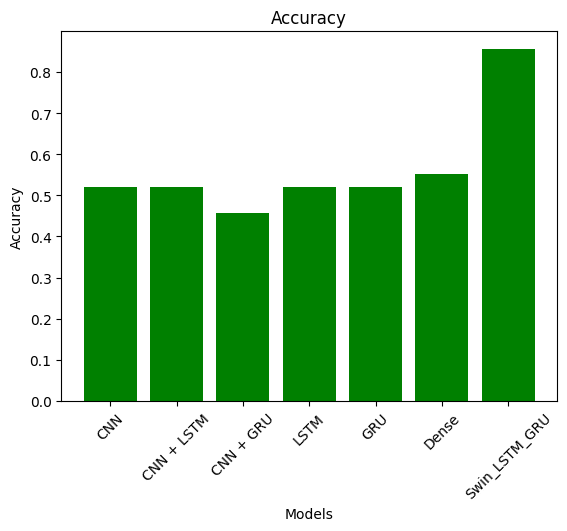

In [73]:
# colors = ['#49D845', '#C94845', '#4958B5', '#F5A623', '#8E44AD', '#16A085']
plt.bar(x='Model', height='Accuracy', data=accuracy, color='g')
plt.title('Accuracy')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
# Show the plot
plt.show()


## Precision

In [74]:
precision = data[['Model','Precision']]

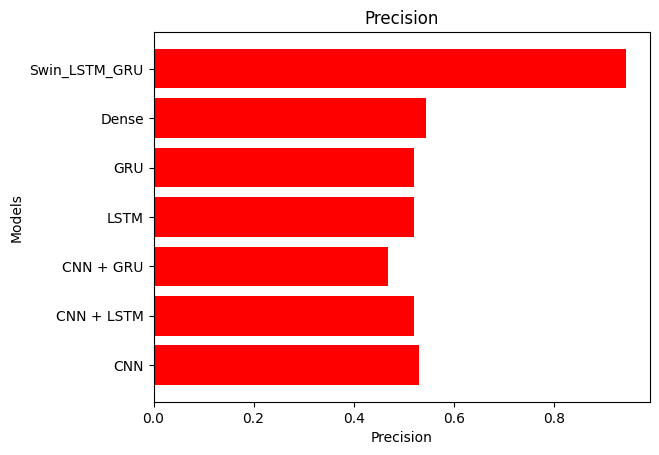

In [75]:
plt.barh(y = 'Model',width = 'Precision', data = precision, color = 'r')
plt.title('Precision')
plt.xlabel('Precision')
plt.ylabel('Models')
plt.show()

## F1 score

In [76]:
f1_score = data[['Model','F1 Score']]

<ipython-input-79-cc9fddc5272e>:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "go--" (-> color='g'). The keyword argument will take precedence.
  plt.plot(f1_score['Model'], f1_score['F1 Score'], 'go--', color = 'c')


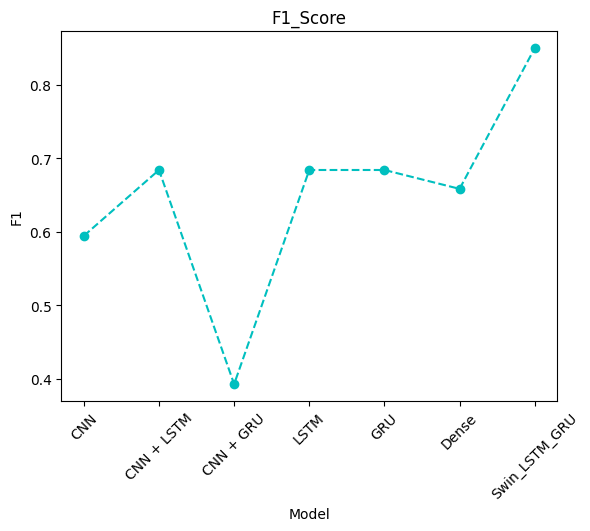

In [79]:
plt.plot(f1_score['Model'], f1_score['F1 Score'], 'go--', color = 'c')
plt.title('F1_Score')
plt.xlabel('Model')
plt.ylabel('F1')
plt.xticks(rotation=45)
plt.show()

## Recall

In [80]:
recall = data[['Model','Recall']]

<ipython-input-82-925d22050dd6>:1: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rs-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(recall['Model'], recall['Recall'], 'rs-', color = 'g')


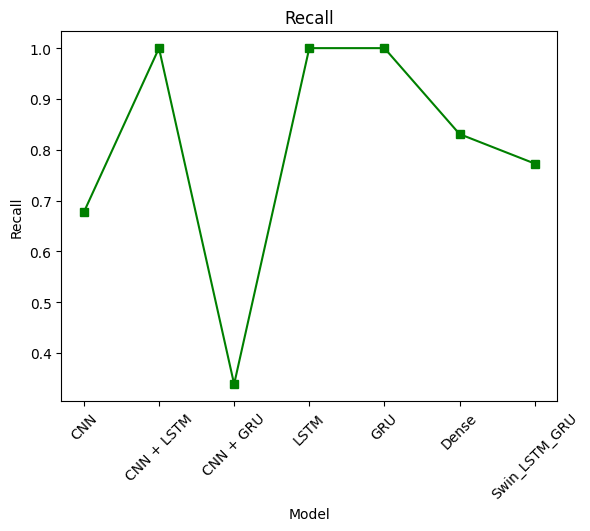

In [82]:
plt.plot(recall['Model'], recall['Recall'], 'rs-', color = 'g')
plt.title('Recall')
plt.xlabel('Model')
plt.ylabel('Recall')
plt.xticks(rotation=45)
# plt.ylim(0.70,0.96)
plt.show()